In [ ]:
1.Scaling of data
2.Check distribution of data- normal distribution
3.Which features are not normally distributed- transform the data log transformation
4. Find correlation between features
5.Which features are contributing to class selection- feature classification
6.C value is a hyper parameter- larger the C value- model becomes strict, making C value 0 makes model very simple making it underfitting. To find the best C value use cross validation

Import linearsvc(penalty = , C= )
Linsvc.fit
Predict

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_excel('Pumpkin_Seeds_Dataset.xlsx')
print(df.head())

    Area  Perimeter  Major_Axis_Length  Minor_Axis_Length  Convex_Area  \
0  56276    888.242           326.1485           220.2388        56831   
1  76631   1068.146           417.1932           234.2289        77280   
2  71623   1082.987           435.8328           211.0457        72663   
3  66458    992.051           381.5638           222.5322        67118   
4  66107    998.146           383.8883           220.4545        67117   

   Equiv_Diameter  Eccentricity  Solidity  Extent  Roundness  Aspect_Ration  \
0        267.6805        0.7376    0.9902  0.7453     0.8963         1.4809   
1        312.3614        0.8275    0.9916  0.7151     0.8440         1.7811   
2        301.9822        0.8749    0.9857  0.7400     0.7674         2.0651   
3        290.8899        0.8123    0.9902  0.7396     0.8486         1.7146   
4        290.1207        0.8187    0.9850  0.6752     0.8338         1.7413   

   Compactness       Class  
0       0.8207  Çerçevelik  
1       0.7487  Çerçev

In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               2500 non-null   int64  
 1   Perimeter          2500 non-null   float64
 2   Major_Axis_Length  2500 non-null   float64
 3   Minor_Axis_Length  2500 non-null   float64
 4   Convex_Area        2500 non-null   int64  
 5   Equiv_Diameter     2500 non-null   float64
 6   Eccentricity       2500 non-null   float64
 7   Solidity           2500 non-null   float64
 8   Extent             2500 non-null   float64
 9   Roundness          2500 non-null   float64
 10  Aspect_Ration      2500 non-null   float64
 11  Compactness        2500 non-null   float64
 12  Class              2500 non-null   object 
dtypes: float64(10), int64(2), object(1)
memory usage: 254.0+ KB
None


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Skewness of features (closer to 0 means more normal):
Area                 0.495999
Perimeter            0.414539
Major_Axis_Length    0.502980
Minor_Axis_Length    0.104303
Convex_Area          0.494016
Equiv_Diameter       0.271868
Eccentricity        -0.748623
Solidity            -5.691009
Extent              -1.026568
Roundness           -0.372687
Aspect_Ration        0.548231
Compactness         -0.062377
dtype: float64


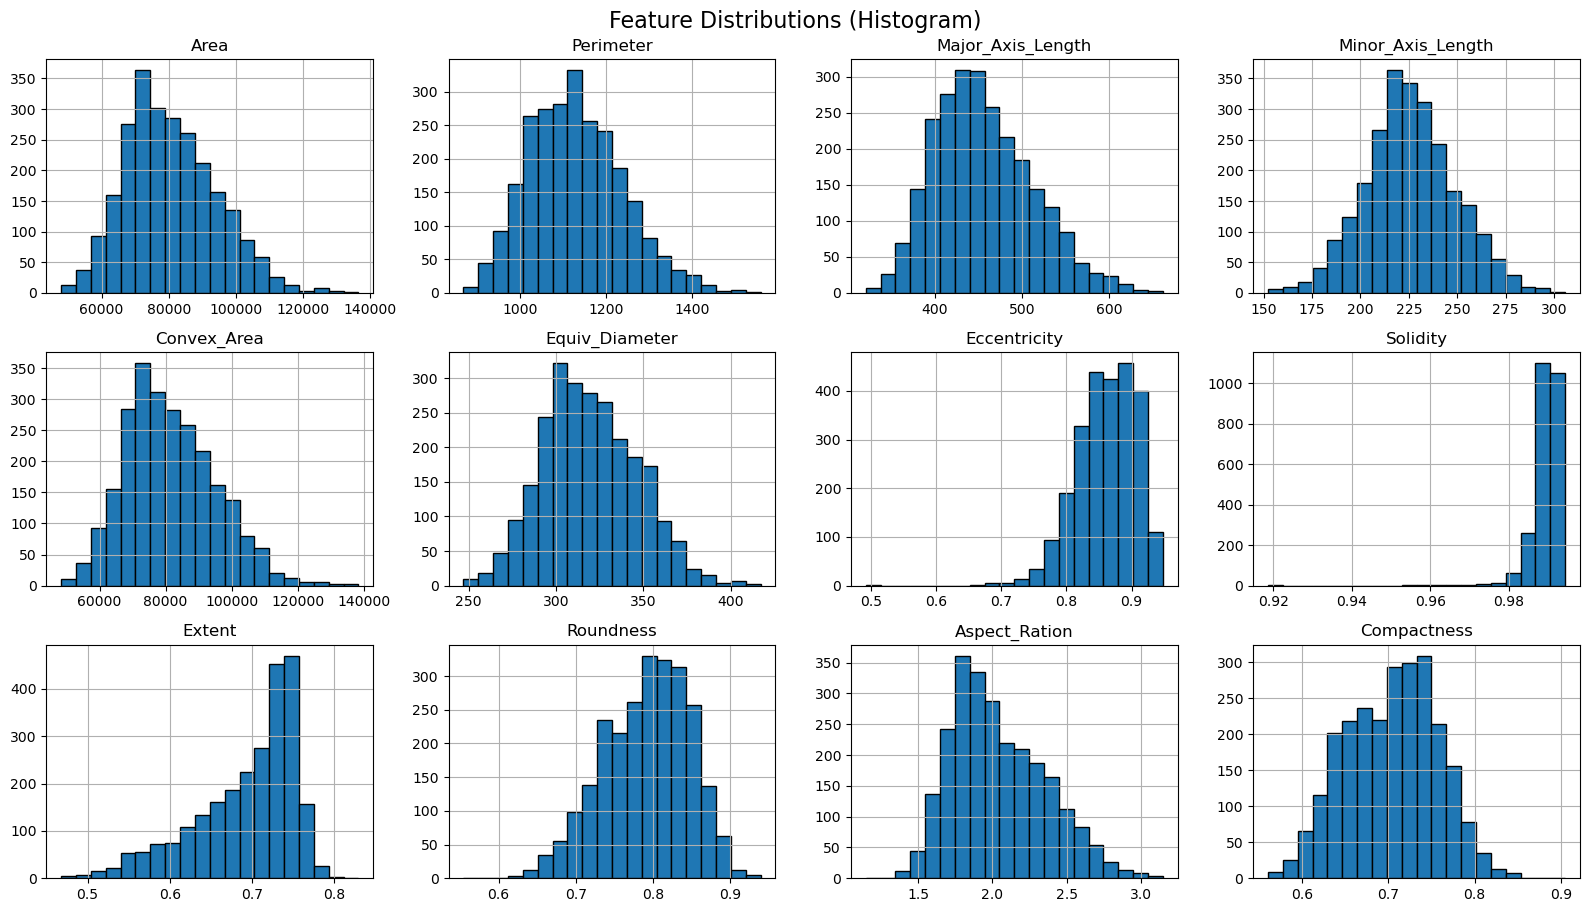

In [21]:
print("Skewness of features (closer to 0 means more normal):")
print(X.skew())
X.hist(bins=20, figsize=(16, 12), layout=(4, 4), edgecolor='black')
plt.suptitle("Feature Distributions (Histogram)", fontsize=16)
plt.tight_layout()
plt.show()

Skewness after log1p transformation:
Major_Axis_Length    0.199208
Eccentricity        -0.882785
Solidity            -5.828322
Extent              -1.103917
Aspect_Ration        0.325441
dtype: float64


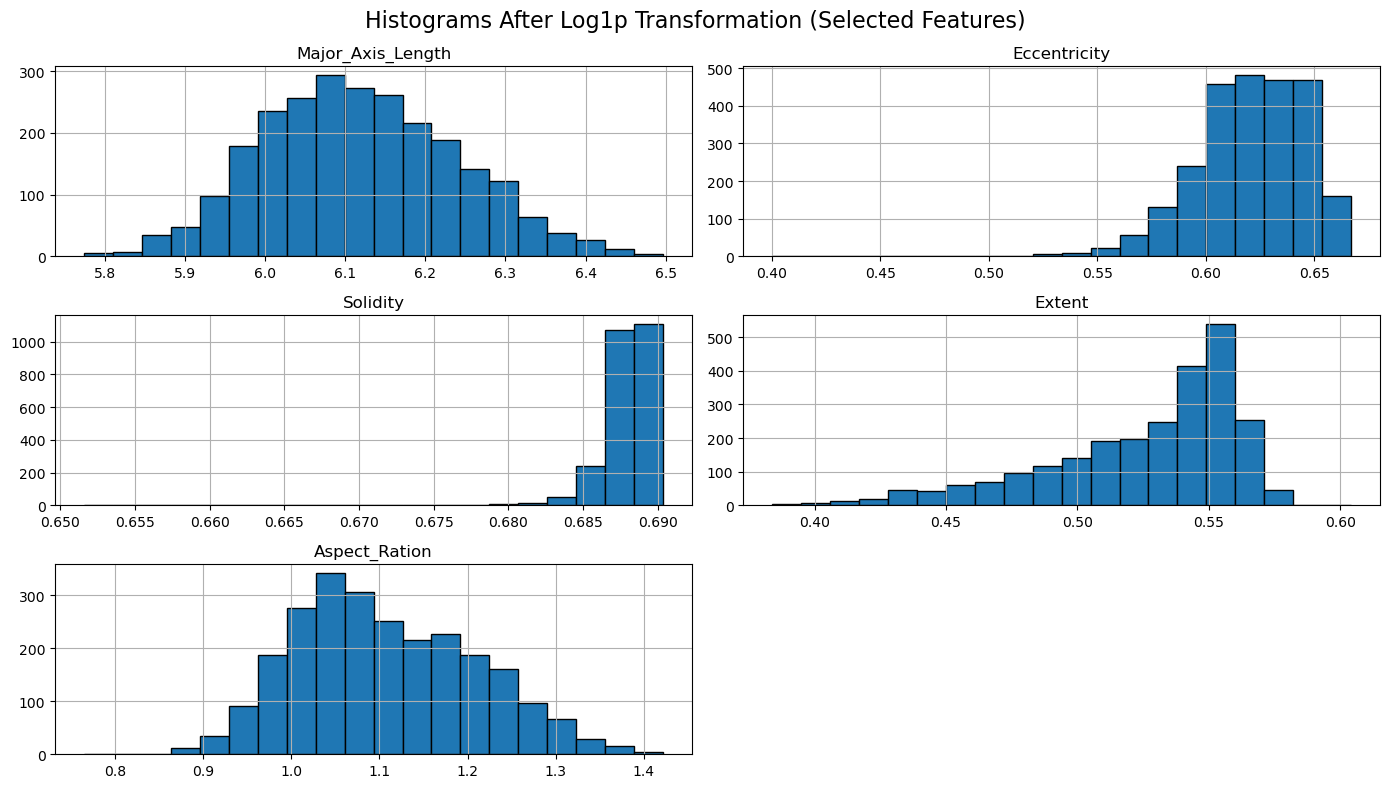

In [22]:
# List of skewed features to transform
skewed_features = ['Major_Axis_Length', 'Eccentricity', 'Solidity', 'Extent', 'Aspect_Ration']

# Apply log1p transformation to only these features
X_log_transformed = X.copy()
X_log_transformed[skewed_features] = np.log1p(X_log_transformed[skewed_features])

# Optional: Check skewness again
print("Skewness after log1p transformation:")
print(X_log_transformed[skewed_features].skew())

# Optional: Plot histograms of transformed features
X_log_transformed[skewed_features].hist(bins=20, figsize=(14, 8), edgecolor='black')
plt.suptitle("Histograms After Log1p Transformation (Selected Features)", fontsize=16)
plt.tight_layout()
plt.show()


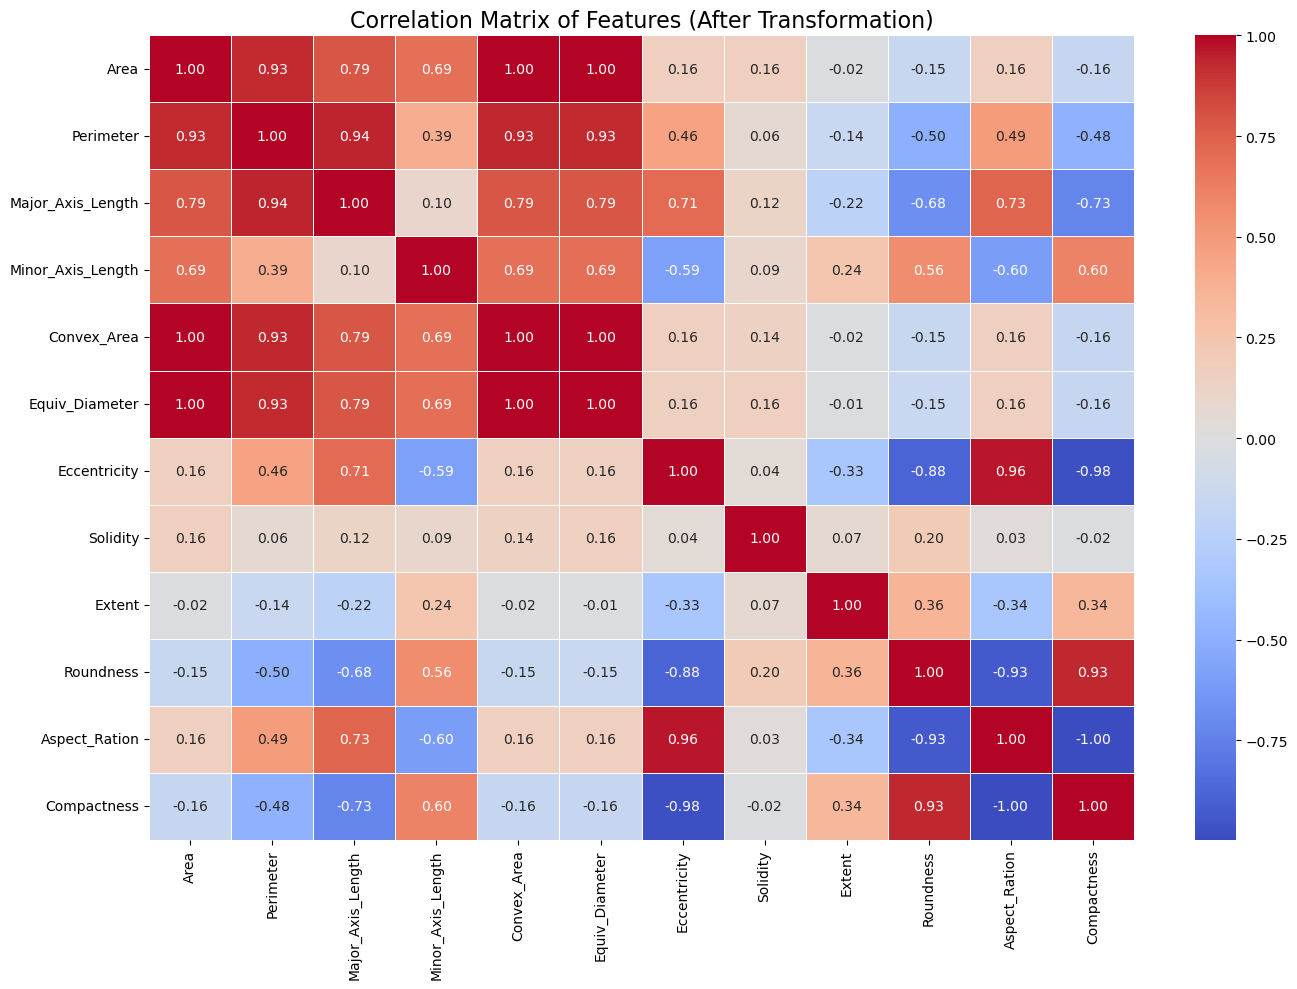

In [23]:
# Compute the correlation matrix
correlation_matrix = X_log_transformed.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Features (After Transformation)", fontsize=16)
plt.tight_layout()
plt.show()


Feature Importance (based on Linear SVM coefficients):
              Feature  Importance
0                Area    2.585254
11        Compactness    2.556489
2   Major_Axis_Length    2.329803
4         Convex_Area    2.310162
10      Aspect_Ration    2.289188
6        Eccentricity    1.952930
5      Equiv_Diameter    1.926253
1           Perimeter    0.954872
9           Roundness    0.583522
3   Minor_Axis_Length    0.509134
7            Solidity    0.493787
8              Extent    0.042330


/var/folders/gm/my8jm43n7j12drtlg3hdcv5h0000gn/T/ipykernel_4593/4290001739.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


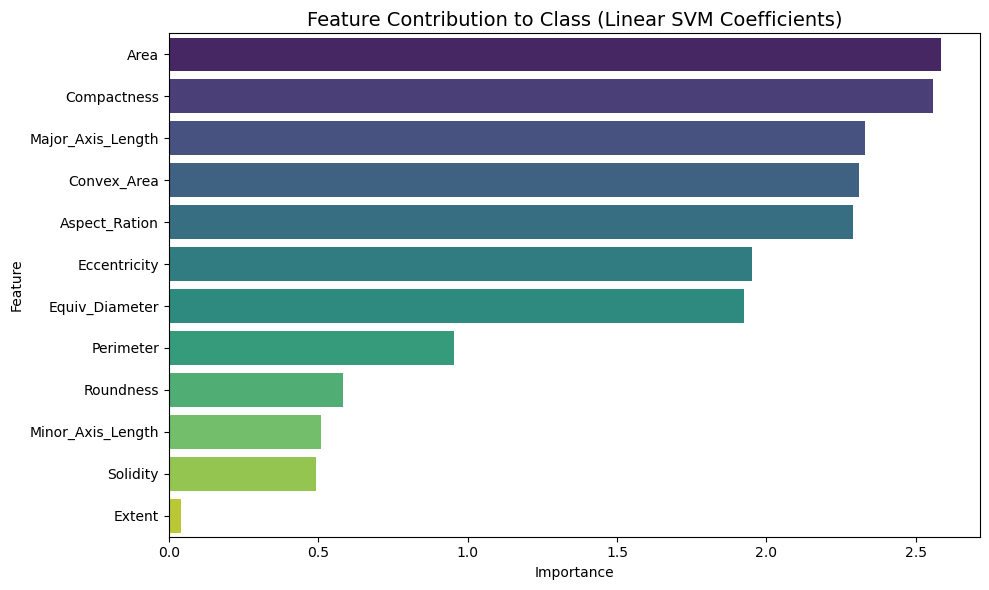

In [24]:
from sklearn.svm import SVC
import numpy as np

# Scale the transformed data
scaler = StandardScaler()
X_scaled_final = scaler.fit_transform(X_log_transformed)

# Train Linear SVM on full scaled dataset (or X_train if preferred)
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_scaled_final, y)

# Get absolute coefficients and match with feature names
coefficients = np.abs(svm.coef_[0])
feature_names = X_log_transformed.columns

# Create a DataFrame for easy viewing
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
}).sort_values(by='Importance', ascending=False)

print("Feature Importance (based on Linear SVM coefficients):")
print(importance_df)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Feature Contribution to Class (Linear SVM Coefficients)", fontsize=14)
plt.tight_layout()
plt.show()


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define parameter grid for C
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Create a linear SVM model
svm = SVC(kernel='linear', random_state=42)

# Grid search with cross-validation (5-fold)
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_scaled_final, y)

# Best C value and corresponding accuracy
print("Best C value:", grid_search.best_params_['C'])
print("Best cross-validated accuracy:", grid_search.best_score_)


Best C value: 10
Best cross-validated accuracy: 0.8852


In [26]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Use the best C value from GridSearch (replace with your found value if known)
best_C = grid_search.best_params_['C']  # or manually: best_C = 1.0

# Initialize LinearSVC with best C and L2 penalty (default)
model = LinearSVC(penalty='l2', C=best_C, max_iter=10000, random_state=42)

# Fit the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)


Test Accuracy: 0.874
